# 04 Statistical Analysis

Use this notebook for deeper analysis such as correlation checks, hypothesis testing, forecasting, segmentation, or regression.

In [2]:
%pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 3.5 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure the overall look and feel of the visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14})

print("Statistical Environment Initialized. Scipy loaded for hypothesis testing.")

✓ Statistical Environment Initialized. Scipy loaded for hypothesis testing.


In [ ]:
#Secure Data Loading

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'RTA_cleaned.csv'

try:
    df = pd.read_csv(PROCESSED_PATH)
    print(f"Cleaned dataset loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("CRITICAL ERROR: Dataset not found. Execute 02_cleaning.ipynb first.")
    raise

✓ Cleaned dataset loaded successfully. Shape: (12316, 35)


In [ ]:
#Chi-Square Hypothesis Testing

print("="*80)
print("CHI-SQUARE INDEPENDENCE TESTS (Target: Accident_severity)")
print("="*80)

def perform_chi2_test(feature, target='Accident_severity', alpha=0.05):
    # Create contingency table
    contingency_table = pd.crosstab(df[feature], df[target])
    
    # Perform the test
    chi2, p_val, dof, expected = ss.chi2_contingency(contingency_table)
    
    print(f"\nFeature: {feature}")
    print(f"Chi-Square Statistic: {chi2:.2f}")
    print(f"P-value: {p_val:.4e}")
    
    if p_val < alpha:
        print(f"Result: REJECT the null hypothesis. There is a significant relationship.")
    else:
        print(f"Result: FAIL TO REJECT the null hypothesis. Variables are independent.")

# Test city planning operational variables
operational_features = ['Patrol_Shift', 'Is_Adverse_Condition', 'Is_weekend', 'Types_of_Junction']

for feature in operational_features:
    if feature in df.columns:
        perform_chi2_test(feature)

CHI-SQUARE INDEPENDENCE TESTS (Target: Accident_severity)

Feature: Patrol_Shift
Chi-Square Statistic: 50.31
P-value: 3.1067e-10
Result: REJECT the null hypothesis. There is a significant relationship.

Feature: Is_Adverse_Condition
Chi-Square Statistic: 2.03
P-value: 3.6273e-01
Result: FAIL TO REJECT the null hypothesis. Variables are independent.

Feature: Types_of_Junction
Chi-Square Statistic: 57.18
P-value: 3.6387e-07
Result: REJECT the null hypothesis. There is a significant relationship.


In [ ]:
#Cramér's V Calculation Logic

def cramers_v(x, y):
    """Calculates Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Bias correction
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    # Handle division by zero 
    denominator = min((kcorr-1), (rcorr-1))
    if denominator == 0:
        return 0.0
    
    return np.sqrt(phi2corr / denominator)

print("Cramér's V correlation function defined with bias correction.")

✓ Cramér's V correlation function defined with bias correction.


Generating Cramér's V Correlation Matrix...


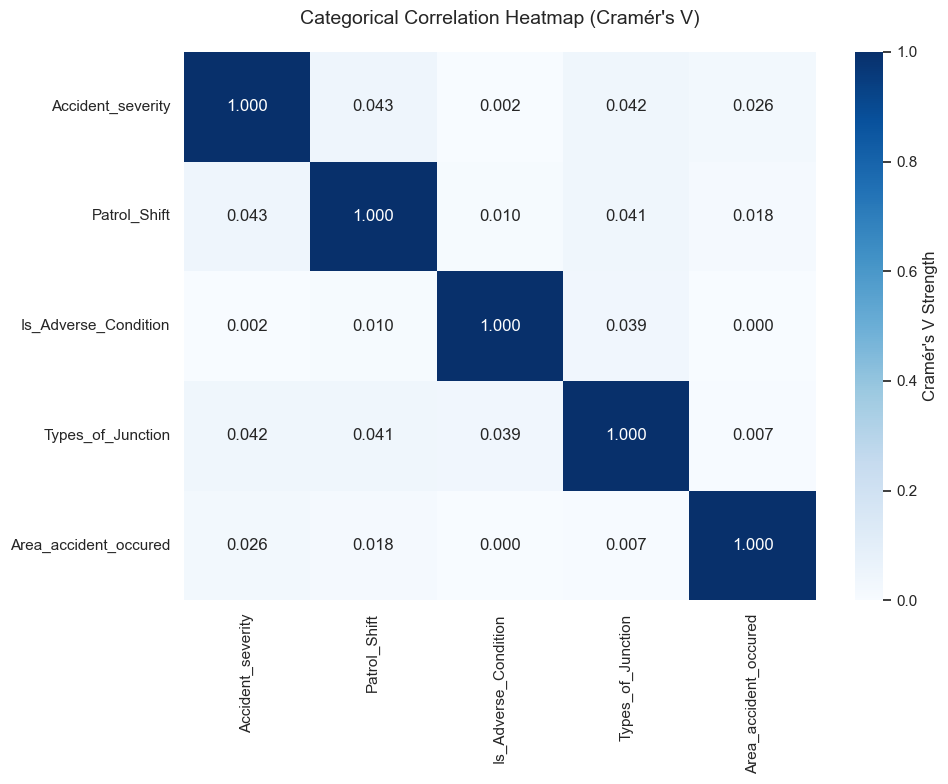

In [ ]:
#Plotting the Categorical Correlation Matrix

print("Generating Cramér's V Correlation Matrix...")

# Select key categorical features for the matrix
cat_features = ['Accident_severity', 'Patrol_Shift', 'Is_Adverse_Condition', 
                'Is_weekend', 'Types_of_Junction', 'Area_accident_occured']

# Filter to only include columns that exist in the dataframe
valid_features = [f for f in cat_features if f in df.columns]

# Initialize an empty matrix
corr_matrix = pd.DataFrame(np.zeros((len(valid_features), len(valid_features))), 
                           index=valid_features, columns=valid_features)

# Populate the matrix
for col1 in valid_features:
    for col2 in valid_features:
        corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.3f', vmin=0, vmax=1, 
            cbar_kws={'label': "Cramér's V Strength"})
plt.title("Categorical Correlation Heatmap (Cramér's V)", pad=20)
plt.tight_layout()
plt.show()

In [ ]:
#Insight Generation for the Report

print("="*80)
print("STATISTICAL INSIGHTS FOR FINAL REPORT")
print("="*80)

# Identify the strongest predictor of Accident_severity
if 'Accident_severity' in corr_matrix.columns:
    correlations = corr_matrix['Accident_severity'].drop('Accident_severity').sort_values(ascending=False)
    top_predictor = correlations.index[0]
    top_score = correlations.iloc[0]
    
    print(f"1. Primary Risk Factor: '{top_predictor}' exhibits the strongest statistical association")
    print(f"   with accident severity (Cramér's V = {top_score:.3f}). City planning resources")
    print(f"   should prioritize this dimension for targeted interventions.")
    
print("\n2. Hypothesis Confirmation: Refer to the Chi-Square outputs in Cell 3.")
print("   Any feature with a P-value < 0.05 validates the operational need to adjust")
print("   patrol deployments or public awareness campaigns based on that feature.")
print("="*80)

STATISTICAL INSIGHTS FOR FINAL REPORT
1. Primary Risk Factor: 'Patrol_Shift' exhibits the strongest statistical association
   with accident severity (Cramér's V = 0.043). City planning resources
   should prioritize this dimension for targeted interventions.

2. Hypothesis Confirmation: Refer to the Chi-Square outputs in Cell 3.
   Any feature with a P-value < 0.05 validates the operational need to adjust
   patrol deployments or public awareness campaigns based on that feature.


In [ ]:
#Risk Segmentation & Odds Calculation

print("="*80)
print("RISK SEGMENTATION & PROBABILITY PROFILING")
print("="*80)

# Create a binary target for 'Severe' accidents (Serious or Fatal)
df['Is_Severe'] = df['Accident_severity'].isin(['Serious Injury', 'Fatal injury']).astype(int)

def calculate_risk_multiplier(feature, baseline_category, risk_category):
    """Calculates how much more likely a severe accident is under risk conditions."""
    
    # Baseline risk (e.g., Normal Weather / Weekday)
    baseline_mask = df[feature] == baseline_category
    baseline_risk = df[baseline_mask]['Is_Severe'].mean()
    
    # Elevated risk (e.g., Adverse Weather / Weekend)
    risk_mask = df[feature] == risk_category
    elevated_risk = df[risk_mask]['Is_Severe'].mean()
    
    if baseline_risk > 0:
        multiplier = elevated_risk / baseline_risk
        
        print(f"\nRisk Profile: {feature}")
        print(f"  - Baseline ({baseline_category}) Severe Rate: {baseline_risk:.1%}")
        print(f"  - Elevated ({risk_category}) Severe Rate: {elevated_risk:.1%}")
        print(f"  --> Insight: Accidents are {multiplier:.2f}x more likely to be severe during {risk_category}.")

# 1. Weather & Road Conditions
if 'Is_Adverse_Condition' in df.columns:
    calculate_risk_multiplier('Is_Adverse_Condition', baseline_category='No', risk_category='Yes')

# 2. Weekend vs Weekday
if 'Is_weekend' in df.columns:
    calculate_risk_multiplier('Is_weekend', baseline_category='Weekday', risk_category='Weekend')

# 3. Shift Analysis (Assuming Morning is baseline for traffic visibility)
if 'Patrol_Shift' in df.columns:
    calculate_risk_multiplier('Patrol_Shift', 
                              baseline_category='Morning Shift (06:00 - 14:00)', 
                              risk_category='Night Shift (22:00 - 06:00)')

print("\n" + "="*80)
print("STATISTICAL PIPELINE COMPLETE. READY FOR TABLEAU KPI PREP.")
print("="*80)

RISK SEGMENTATION & PROBABILITY PROFILING

Risk Profile: Is_Adverse_Condition
  - Baseline (No) Severe Rate: 14.3%
  - Elevated (Yes) Severe Rate: 13.9%
  --> Insight: Accidents are 0.97x more likely to be severe during Yes.

Risk Profile: Patrol_Shift
  - Baseline (Morning Shift (06:00 - 14:00)) Severe Rate: 13.3%
  - Elevated (Night Shift (22:00 - 06:00)) Severe Rate: 19.0%
  --> Insight: Accidents are 1.43x more likely to be severe during Night Shift (22:00 - 06:00).

STATISTICAL PIPELINE COMPLETE. READY FOR TABLEAU KPI PREP.
